# RAG Evaluation with RAGAS + ChromaDB + GPT-4o-mini

**Stack:** ChromaDB · OpenAI `text-embedding-3-small` · `gpt-4o-mini` · RAGAS v0.2+

| Metric | What it measures | Needs ground truth? |
|---|---|---|
| `faithfulness` | Answer is grounded in context (no hallucination) | No |
| `answer_relevancy` | Answer is on-topic for the question | No |
| `context_precision` | Retrieved chunks are useful and well-ranked | Yes |
| `context_recall` | Context fully covers the ground truth | Yes |
| `answer_correctness` | Answer matches ground truth factually | Yes |

This notebook uses **mixed-quality** Q&A pairs — some good, some partial, some intentionally unanswerable — so scores are **realistic and varied** (not all 1.0).

## 1. Install Dependencies

In [1]:
import sys
print(sys.executable)

c:\Users\AadharJain\Desktop\IBM_Training-main\.venv312\Scripts\python.exe


In [2]:
# !pip install -q \
#     "ragas>=0.2.0" \
#     "chromadb>=0.5.0" \
#     "openai>=1.30.0" \
#     "langchain-openai>=0.1.0" \
#     "datasets>=2.14.0" \
#     "tiktoken" \
#     "pandas" \
#     "matplotlib"

# print('Done')

## 2. Imports and API Key

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from dotenv import load_dotenv
import chromadb
from chromadb.utils import embedding_functions
load_dotenv()
import chromadb
from chromadb.utils import embedding_functions
from openai import OpenAI

# RAGAS v0.2+ uses class-based metrics and EvaluationDataset
from ragas.evaluation import evaluate
from ragas.dataset_schema import EvaluationDataset, SingleTurnSample
from ragas.metrics import (
    Faithfulness,
    AnswerRelevancy,
    LLMContextPrecisionWithReference,
    LLMContextRecall,
    AnswerCorrectness,
)
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

print('All imports OK')

from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

ragas_llm = LangchainLLMWrapper(llm)
ragas_emb = LangchainEmbeddingsWrapper(embeddings)

# Instantiate each metric as an object (required in RAGAS v0.2+)
metric_faithfulness       = Faithfulness(llm=ragas_llm)
metric_answer_relevancy   = AnswerRelevancy(llm=ragas_llm, embeddings=ragas_emb)
metric_context_precision  = LLMContextPrecisionWithReference(llm=ragas_llm)
metric_context_recall     = LLMContextRecall(llm=ragas_llm)
metric_answer_correctness = AnswerCorrectness(llm=ragas_llm, embeddings=ragas_emb)

print('RAGAS metrics instantiated')

All imports OK
RAGAS metrics instantiated


In [3]:
def list_available_models():
    try:
        # Initialize the OpenAI client
        client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

        # Fetch the list of models
        models = client.models.list()

        print("✅ Models available for your API key:\n")
        for model in models.data:
            if "5" in model.id:
                print(f"- {model.id}")

    except Exception as e:
        print(f"❌ Error fetching models: {e}")

list_available_models()

✅ Models available for your API key:

- gpt-3.5-turbo
- gpt-3.5-turbo-16k
- gpt-3.5-turbo-instruct
- gpt-3.5-turbo-instruct-0914
- gpt-3.5-turbo-1106
- gpt-3.5-turbo-0125
- gpt-4o-2024-05-13
- o3-mini-2025-01-31
- computer-use-preview-2025-03-11
- gpt-4o-mini-search-preview-2025-03-11
- o1-pro-2025-03-19
- o3-2025-04-16
- o4-mini-2025-04-16
- gpt-4.1-2025-04-14
- gpt-4.1-mini-2025-04-14
- gpt-4.1-nano-2025-04-14
- o3-pro-2025-06-10
- o3-deep-research-2025-06-26
- o4-mini-deep-research-2025-06-26
- gpt-5-chat-latest
- gpt-5-2025-08-07
- gpt-5
- gpt-5-mini-2025-08-07
- gpt-5-mini
- gpt-5-nano-2025-08-07
- gpt-5-nano
- gpt-audio-2025-08-28
- gpt-realtime-2025-08-28
- gpt-5-codex
- gpt-5-pro-2025-10-06
- gpt-5-pro
- gpt-audio-mini-2025-10-06
- gpt-5-search-api
- gpt-5-search-api-2025-10-14
- gpt-5.1-chat-latest
- gpt-5.1-2025-11-13
- gpt-5.1
- gpt-5.1-codex
- gpt-5.1-codex-mini
- gpt-5.1-codex-max
- gpt-image-1.5
- gpt-5.2-2025-12-11
- gpt-5.2
- gpt-5.2-pro-2025-12-11
- gpt-5.2-pro
- gpt-5

In [4]:
print(type(metric_faithfulness.llm))

<class 'ragas.llms.base.LangchainLLMWrapper'>


## 3. Knowledge Base

A small corpus about RAG / ML topics.  
**Important:** some questions asked later are NOT covered here — that is intentional, so the retriever returns irrelevant context and scores drop realistically.

In [5]:
documents = [
    # doc_0
    "Retrieval-Augmented Generation (RAG) is an AI framework that enhances large language models "
    "by connecting them to external knowledge bases. Instead of relying solely on parametric memory, "
    "RAG retrieves relevant documents at inference time and conditions the generation on them.",

    # doc_1
    "ChromaDB is an open-source, AI-native vector database. It allows developers to store embeddings "
    "alongside metadata and perform low-latency similarity searches. ChromaDB can run in-memory or "
    "persisted to disk and integrates natively with LangChain and LlamaIndex.",

    # doc_2
    "GPT-4o-mini is a small, cost-efficient multimodal model released by OpenAI in July 2024. "
    "It scores 82% on the MMLU benchmark, supports a 128k context length, and achieves better "
    "performance than GPT-3.5 Turbo while being significantly cheaper than GPT-4o.",

    # doc_3
    "RAGAS (Retrieval Augmented Generation Assessment) is an open-source Python framework for "
    "evaluating RAG pipelines. It measures faithfulness, answer relevancy, context precision, "
    "context recall, and answer correctness using LLM-based judges.",

    # doc_4
    "Faithfulness in RAGAS checks whether every claim in the generated answer can be inferred "
    "from the retrieved context. It decomposes the answer into atomic claims and verifies each "
    "one. A score of 1.0 means zero hallucination.",

    # doc_5
    "Context recall measures what fraction of the ground-truth answer's key claims are covered "
    "by the retrieved context. A low context recall means the retriever failed to fetch documents "
    "containing the information needed to answer the question.",

    # doc_6
    "Vector embeddings are dense numerical representations of text or other data. "
    "They capture semantic meaning so that similar items cluster together in the embedding space "
    "and can be found with similarity search.",

    # doc_7  intentionally off-topic to pollute retrieval for hard questions
    "The Python programming language was created by Guido van Rossum and first released in 1991. "
    "Python emphasises code readability and uses significant indentation. It supports procedural, "
    "object-oriented, and functional programming paradigms.",

    # doc_8  partial info only
    "Chunking strategies in RAG include fixed-size chunking, sentence-level chunking, and "
    "semantic chunking. The chunk size significantly affects retrieval quality.",

    # doc_9
    "LangChain is a framework for building LLM-powered applications. It provides abstractions "
    "for chains, agents, retrievers, and memory modules that simplify complex workflows.",
]

doc_ids = [f'doc_{i}' for i in range(len(documents))]
print(f'{len(documents)} documents ready')

10 documents ready


## 4. Build ChromaDB Vector Store

In [6]:
openai_ef = embedding_functions.OpenAIEmbeddingFunction(
    api_key=os.environ['OPENAI_API_KEY'],
    model_name='text-embedding-3-small'
)

# EphemeralClient = in-memory, no persistence needed for Colab
chroma_client = chromadb.EphemeralClient()

try:
    chroma_client.delete_collection("rag_kb")
except:
    pass

collection = chroma_client.create_collection(
    name="rag_kb",
    embedding_function=openai_ef,
    metadata={"hnsw:space": "cosine"}
)

collection.add(documents=documents, ids=doc_ids)
print(f'ChromaDB collection: {collection.count()} documents')

ChromaDB collection: 10 documents


## 5. RAG Pipeline

In [7]:
oai_client = OpenAI()

def retrieve(query: str, n_results: int = 3):
    """Retrieve top-k chunks from ChromaDB."""
    res = collection.query(query_texts=[query], n_results=n_results)
    return res['documents'][0]   # list[str]


def generate(query: str, context_chunks: list, temperature: float = 0.0):
    """Generate an answer with gpt-4o-mini, grounded in context."""
    context = '\n\n'.join(context_chunks)
    system  = (
        'You are a helpful assistant. '
        'Answer using ONLY the context provided. '
        'If the context does not contain enough information, '
        'say exactly: "The context does not contain this information."'
    )
    user = f'Context:\n{context}\n\nQuestion: {query}\nAnswer:'
    resp = oai_client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{'role': 'system', 'content': system},
                  {'role': 'user',   'content': user}],
        temperature=temperature,
    )
    return resp.choices[0].message.content.strip()


def rag(query: str, n_results: int = 3):
    """Full RAG pipeline."""
    contexts = retrieve(query, n_results)
    answer   = generate(query, contexts)
    return answer, contexts


# Quick smoke test
q = 'What is ChromaDB?'
a, ctx = rag(q)
print(f'Q: {q}\nA: {a}\n')
for i, c in enumerate(ctx, 1):
    print(f'  [{i}] {c[:90]}...')

Q: What is ChromaDB?
A: ChromaDB is an open-source, AI-native vector database that allows developers to store embeddings alongside metadata and perform low-latency similarity searches. It can run in-memory or be persisted to disk and integrates natively with LangChain and LlamaIndex.

  [1] ChromaDB is an open-source, AI-native vector database. It allows developers to store embed...
  [2] LangChain is a framework for building LLM-powered applications. It provides abstractions f...
  [3] RAGAS (Retrieval Augmented Generation Assessment) is an open-source Python framework for e...


## 6. Mixed-Quality Evaluation Dataset

Three tiers:
- **good** — answer is fully in the KB → expect high scores across all metrics  
- **medium** — answer is only partially in the KB → middle scores  
- **bad** — answer is NOT in the KB at all → the model should say it doesn't know, causing low relevancy, recall, and correctness

In [8]:
eval_set = [
    # ---- GOOD: fully covered by KB ----------------------------------------
    {
        'question':     'What is ChromaDB and what are its main features?',
        'ground_truth': 'ChromaDB is an open-source AI-native vector database that stores embeddings '
                        'alongside metadata and performs low-latency similarity search. It can run '
                        'in-memory or persisted to disk and integrates with LangChain and LlamaIndex.',
        'quality':      'good',
    },
    {
        'question':     'What does faithfulness measure in RAGAS and what does a score of 1.0 mean?',
        'ground_truth': 'Faithfulness checks whether every claim in the generated answer can be '
                        'inferred from the retrieved context by decomposing the answer into atomic '
                        'claims and verifying each one. A score of 1.0 means zero hallucination.',
        'quality':      'good',
    },

    # ---- MEDIUM: partially covered -----------------------------------------
    {
        'question':     'What chunking strategies exist in RAG and how do they affect quality?',
        'ground_truth': 'Common chunking strategies include fixed-size, sentence-level, and semantic '
                        'chunking. Chunk size significantly affects retrieval quality. Smaller chunks '
                        'improve precision while larger chunks improve recall but may add noise. '
                        'Overlap between chunks helps preserve continuity across chunk boundaries.',
        'quality':      'medium',  # KB only has 1 partial sentence on this
    },
    {
        'question':     'How does GPT-4o-mini compare with GPT-4o in terms of cost and performance?',
        'ground_truth': 'GPT-4o-mini is significantly cheaper than GPT-4o and scores 82% on MMLU. '
                        'It outperforms GPT-3.5 Turbo. However GPT-4o-mini lacks some advanced '
                        'reasoning capabilities that GPT-4o has, and GPT-4o supports longer context '
                        'windows and better multilingual performance.',
        'quality':      'medium',  # KB has partial comparison info
    },

    # ---- BAD: answer NOT in KB at all → retriever returns irrelevant chunks -
    {
        'question':     'What is the price per million tokens for GPT-4o-mini on the OpenAI API?',
        'ground_truth': 'GPT-4o-mini costs $0.15 per million input tokens and $0.60 per million '
                        'output tokens via the OpenAI API as of mid-2024.',
        'quality':      'bad',   # pricing info not in KB
    },
    {
        'question':     'How do you implement multi-hop reasoning in a RAG pipeline?',
        'ground_truth': 'Multi-hop RAG decomposes complex questions into sub-questions, retrieves '
                        'evidence for each sub-question separately, and chains the results across '
                        'multiple retrieval steps before generating a final answer. Common approaches '
                        'include iterative retrieval and graph-based reasoning over documents.',
        'quality':      'bad',   # completely absent from KB
    },
]

print(f'Evaluation set: {len(eval_set)} samples')
for i, s in enumerate(eval_set):
    print(f"  Q{i+1} [{s['quality']:6s}] {s['question'][:65]}")

Evaluation set: 6 samples
  Q1 [good  ] What is ChromaDB and what are its main features?
  Q2 [good  ] What does faithfulness measure in RAGAS and what does a score of 
  Q3 [medium] What chunking strategies exist in RAG and how do they affect qual
  Q4 [medium] How does GPT-4o-mini compare with GPT-4o in terms of cost and per
  Q5 [bad   ] What is the price per million tokens for GPT-4o-mini on the OpenA
  Q6 [bad   ] How do you implement multi-hop reasoning in a RAG pipeline?


## 7. Run RAG on All Questions

In [9]:
print('Running RAG pipeline...\n')
for i, sample in enumerate(eval_set):
    answer, contexts = rag(sample['question'], n_results=3)
    sample['answer']   = answer
    sample['contexts'] = contexts
    print(f"Q{i+1} [{sample['quality']:6s}]: {sample['question'][:60]}")
    print(f"Answer        : {answer[:120]}")
    print()

print('RAG complete for all samples.')

Running RAG pipeline...

Q1 [good  ]: What is ChromaDB and what are its main features?
Answer        : ChromaDB is an open-source, AI-native vector database that allows developers to store embeddings alongside metadata and 

Q2 [good  ]: What does faithfulness measure in RAGAS and what does a scor
Answer        : Faithfulness in RAGAS measures whether every claim in the generated answer can be inferred from the retrieved context. A

Q3 [medium]: What chunking strategies exist in RAG and how do they affect
Answer        : Chunking strategies in RAG include fixed-size chunking, sentence-level chunking, and semantic chunking. The chunk size s

Q4 [medium]: How does GPT-4o-mini compare with GPT-4o in terms of cost an
Answer        : GPT-4o-mini is significantly cheaper than GPT-4o while achieving better performance than GPT-3.5 Turbo. The context does

Q5 [bad   ]: What is the price per million tokens for GPT-4o-mini on the 
Answer        : The context does not contain this information.

Q

## 8. Build RAGAS EvaluationDataset

RAGAS v0.2+ requires `SingleTurnSample` objects wrapped in an `EvaluationDataset` — not a raw HuggingFace `Dataset`.

In [10]:
ragas_samples = [
    SingleTurnSample(
        user_input         = s['question'],
        response           = s['answer'],
        retrieved_contexts = s['contexts'],   # list[str]
        reference          = s['ground_truth'],
    )
    for s in eval_set
]

ragas_dataset = EvaluationDataset(samples=ragas_samples)
print(f'EvaluationDataset: {len(ragas_dataset.samples)} samples')

EvaluationDataset: 6 samples


---
## 9. Evaluate — Metric by Metric

---
### 9.1 Faithfulness

Checks every claim in the answer against the retrieved context.  
Expected pattern: `good` > `medium` > `bad`  
When the model says "The context does not contain this information", it makes no claims, so faithfulness may be `NaN` or `1.0` — we handle that below.

In [11]:
type(ragas_llm)
type(metric_faithfulness.llm)

ragas.llms.base.LangchainLLMWrapper

In [12]:
res_faith = evaluate(dataset=ragas_dataset, metrics=[metric_faithfulness])
df_faith  = res_faith.to_pandas()

print('=' * 60)
print('FAITHFULNESS')
print('=' * 60)
for i, row in df_faith.iterrows():
    q = eval_set[i]
    score = row.get('faithfulness', float('nan'))
    print(f"  Q{i+1} [{q['quality']:6s}]  {score:.4f}  |  {q['question'][:55]}")

print(f"\n  Mean Faithfulness = {df_faith['faithfulness'].mean():.4f}")

Evaluating: 100%|██████████| 6/6 [00:07<00:00,  1.30s/it]

FAITHFULNESS
  Q1 [good  ]  1.0000  |  What is ChromaDB and what are its main features?
  Q2 [good  ]  1.0000  |  What does faithfulness measure in RAGAS and what does a
  Q3 [medium]  1.0000  |  What chunking strategies exist in RAG and how do they a
  Q4 [medium]  1.0000  |  How does GPT-4o-mini compare with GPT-4o in terms of co
  Q5 [bad   ]  1.0000  |  What is the price per million tokens for GPT-4o-mini on
  Q6 [bad   ]  1.0000  |  How do you implement multi-hop reasoning in a RAG pipel

  Mean Faithfulness = 1.0000


---
### 9.2 Answer Relevancy

Measures how well the answer addresses the question using embedding similarity.  
"The context does not contain this information" responses score **low** here.

In [13]:
res_rel = evaluate(dataset=ragas_dataset, metrics=[metric_answer_relevancy])
df_rel  = res_rel.to_pandas()

print('=' * 60)
print('ANSWER RELEVANCY')
print('=' * 60)
for i, row in df_rel.iterrows():
    q = eval_set[i]
    score = row.get('answer_relevancy', float('nan'))
    print(f"  Q{i+1} [{q['quality']:6s}]  {score:.4f}  |  {q['question'][:55]}")

print(f"\n  Mean Answer Relevancy = {df_rel['answer_relevancy'].mean():.4f}")

Evaluating: 100%|██████████| 6/6 [00:08<00:00,  1.37s/it]


ANSWER RELEVANCY
  Q1 [good  ]  1.0000  |  What is ChromaDB and what are its main features?
  Q2 [good  ]  0.8899  |  What does faithfulness measure in RAGAS and what does a
  Q3 [medium]  0.9130  |  What chunking strategies exist in RAG and how do they a
  Q4 [medium]  0.0000  |  How does GPT-4o-mini compare with GPT-4o in terms of co
  Q5 [bad   ]  0.0000  |  What is the price per million tokens for GPT-4o-mini on
  Q6 [bad   ]  0.0000  |  How do you implement multi-hop reasoning in a RAG pipel

  Mean Answer Relevancy = 0.4672


---
### 9.3 Context Precision

Are the retrieved chunks actually relevant to the ground truth?  
For `bad` questions the retriever pulls tangentially-related chunks → **low precision**.

In [14]:
res_prec = evaluate(dataset=ragas_dataset, metrics=[metric_context_precision])
df_prec  = res_prec.to_pandas()

print('=' * 60)
print('CONTEXT PRECISION')
print('=' * 60)
for i, row in df_prec.iterrows():
    q = eval_set[i]
    score = row.get('llm_context_precision_with_reference', float('nan'))
    print(f"  Q{i+1} [{q['quality']:6s}]  {score:.4f}  |  {q['question'][:55]}")

print(f"\n  Mean Context Precision = {df_prec['llm_context_precision_with_reference'].mean():.4f}")

Evaluating: 100%|██████████| 6/6 [00:05<00:00,  1.10it/s]


CONTEXT PRECISION
  Q1 [good  ]  1.0000  |  What is ChromaDB and what are its main features?
  Q2 [good  ]  1.0000  |  What does faithfulness measure in RAGAS and what does a
  Q3 [medium]  1.0000  |  What chunking strategies exist in RAG and how do they a
  Q4 [medium]  1.0000  |  How does GPT-4o-mini compare with GPT-4o in terms of co
  Q5 [bad   ]  0.0000  |  What is the price per million tokens for GPT-4o-mini on
  Q6 [bad   ]  0.0000  |  How do you implement multi-hop reasoning in a RAG pipel

  Mean Context Precision = 0.6667


---
### 9.4 Context Recall

Does the retrieved context cover all the facts in the ground truth?  
When the answer is absent from the KB, recall is **near 0**.

In [15]:
res_rec = evaluate(dataset=ragas_dataset, metrics=[metric_context_recall])
df_rec  = res_rec.to_pandas()

print('=' * 60)
print('CONTEXT RECALL')
print('=' * 60)
for i, row in df_rec.iterrows():
    q = eval_set[i]
    score = row.get('context_recall', float('nan'))
    print(f"  Q{i+1} [{q['quality']:6s}]  {score:.4f}  |  {q['question'][:55]}")

print(f"\n  Mean Context Recall = {df_rec['context_recall'].mean():.4f}")

Evaluating: 100%|██████████| 6/6 [00:02<00:00,  2.11it/s]

CONTEXT RECALL
  Q1 [good  ]  1.0000  |  What is ChromaDB and what are its main features?
  Q2 [good  ]  1.0000  |  What does faithfulness measure in RAGAS and what does a
  Q3 [medium]  0.5000  |  What chunking strategies exist in RAG and how do they a
  Q4 [medium]  0.5000  |  How does GPT-4o-mini compare with GPT-4o in terms of co
  Q5 [bad   ]  0.0000  |  What is the price per million tokens for GPT-4o-mini on
  Q6 [bad   ]  0.0000  |  How do you implement multi-hop reasoning in a RAG pipel

  Mean Context Recall = 0.5000


---
### 9.5 Answer Correctness

Combines factual overlap and semantic similarity against the ground truth.  
Worst scores expected for `bad` tier where the model answers "I don't know".

In [16]:
metric_answer_correctness = AnswerCorrectness(llm=ragas_llm, embeddings=ragas_emb)

res_corr = evaluate(dataset=ragas_dataset, metrics=[metric_answer_correctness])
df_corr  = res_corr.to_pandas()

print('=' * 60)
print('ANSWER CORRECTNESS')
print('=' * 60)
for i, row in df_corr.iterrows():
    q = eval_set[i]
    score = row.get('answer_correctness', float('nan'))
    print(f"  Q{i+1} [{q['quality']:6s}]  {score:.4f}  |  {q['question'][:55]}")

print(f"\n  Mean Answer Correctness = {df_corr['answer_correctness'].mean():.4f}")

Evaluating: 100%|██████████| 6/6 [00:08<00:00,  1.39s/it]


ANSWER CORRECTNESS
  Q1 [good  ]  0.9966  |  What is ChromaDB and what are its main features?
  Q2 [good  ]  0.6997  |  What does faithfulness measure in RAGAS and what does a
  Q3 [medium]  0.7114  |  What chunking strategies exist in RAG and how do they a
  Q4 [medium]  0.4996  |  How does GPT-4o-mini compare with GPT-4o in terms of co
  Q5 [bad   ]  0.0225  |  What is the price per million tokens for GPT-4o-mini on
  Q6 [bad   ]  0.0270  |  How do you implement multi-hop reasoning in a RAG pipel

  Mean Answer Correctness = 0.4928


---
## 10. Full Combined Evaluation

In [17]:
all_metrics = [
    metric_faithfulness,
    metric_answer_relevancy,
    metric_context_precision,
    metric_context_recall,
    metric_answer_correctness,
]

res_all = evaluate(dataset=ragas_dataset, metrics=all_metrics)
df_all  = res_all.to_pandas()

# ── Debug: see exactly what columns RAGAS returned ──────────────────────────
print("Actual columns:", df_all.columns.tolist())

# ── Auto-detect metric columns (exclude non-metric cols) ────────────────────
non_metric_cols = {'user_input', 'retrieved_contexts', 'response', 'reference',
                   'question', 'answer', 'contexts', 'ground_truth', 'ground_truths'}
metric_cols = [c for c in df_all.columns if c not in non_metric_cols]
print("Detected metric cols:", metric_cols)

# ── Attach quality tier ──────────────────────────────────────────────────────
df_all['quality']        = [s['quality']               for s in eval_set]
df_all['question_short'] = [s['question'][:48] + '...' for s in eval_set]

display_cols = ['quality', 'question_short'] + metric_cols
print('\nFULL RAGAS RESULTS')
print('=' * 110)
print(df_all[display_cols].to_string(index=False))

print('\nMEAN SCORES BY QUALITY TIER')
print(df_all.groupby('quality')[metric_cols].mean().round(4).to_string())

print('\nOVERALL MEAN SCORES')
for col in metric_cols:
    val = df_all[col].mean()
    bar = '|' * int(val * 25)
    print(f'  {col:<35}: {val:.4f}  {bar}')

Evaluating: 100%|██████████| 30/30 [00:16<00:00,  1.78it/s]


Actual columns: ['user_input', 'retrieved_contexts', 'response', 'reference', 'faithfulness', 'answer_relevancy', 'llm_context_precision_with_reference', 'context_recall', 'answer_correctness']
Detected metric cols: ['faithfulness', 'answer_relevancy', 'llm_context_precision_with_reference', 'context_recall', 'answer_correctness']

FULL RAGAS RESULTS
quality                                      question_short  faithfulness  answer_relevancy  llm_context_precision_with_reference  context_recall  answer_correctness
   good What is ChromaDB and what are its main features?...          1.00          1.000000                                   1.0             1.0            0.996630
   good What does faithfulness measure in RAGAS and what...          1.00          0.853243                                   1.0             1.0            0.699675
 medium What chunking strategies exist in RAG and how do...          1.00          0.913026                                   1.0             0.5    

## 11. Visualization

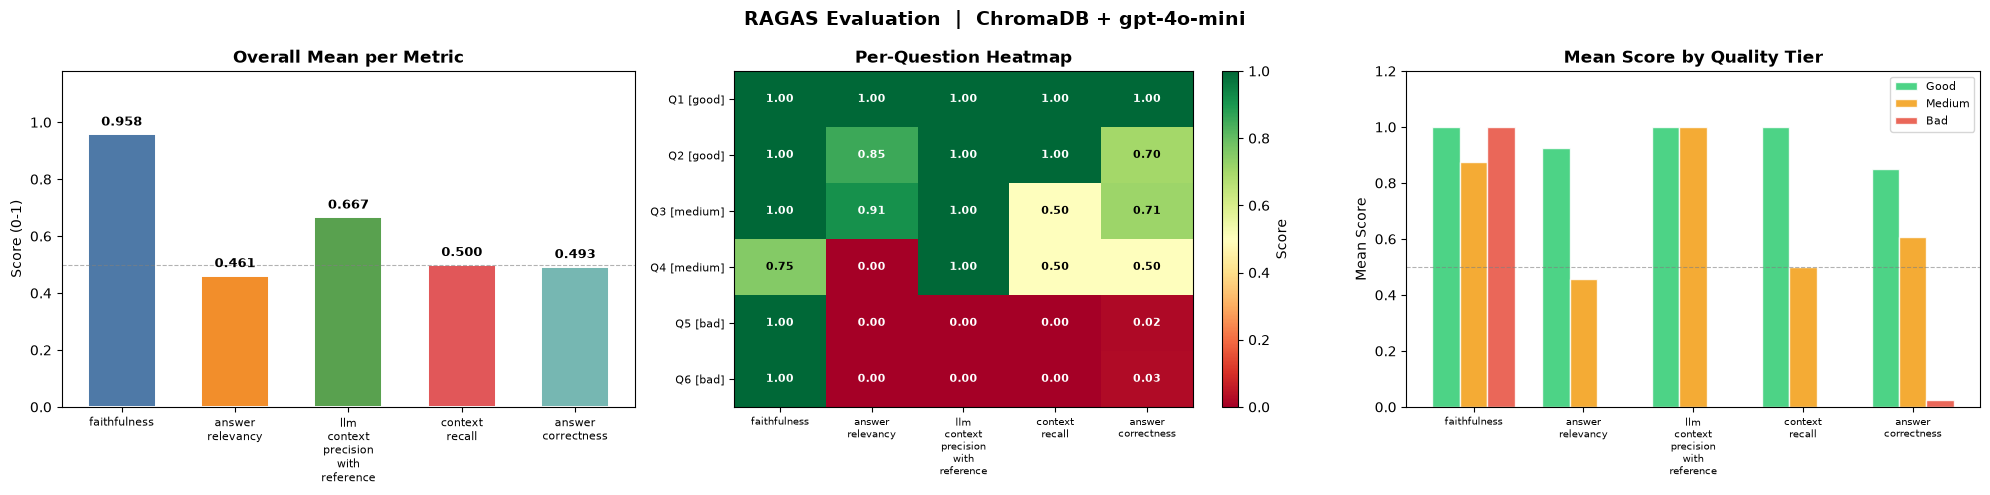

Plot saved as ragas_results.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('RAGAS Evaluation  |  ChromaDB + gpt-4o-mini', fontsize=14, fontweight='bold')

metric_colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759', '#76b7b2']
tier_color    = {'good': '#2ecc71', 'medium': '#f39c12', 'bad': '#e74c3c'}

# --- Plot 1: overall mean per metric ---
means = df_all[metric_cols].mean()
bars  = axes[0].bar(range(len(metric_cols)), means.values,
                    color=metric_colors, edgecolor='white', linewidth=1.4, width=0.6)
axes[0].set_xticks(range(len(metric_cols)))
axes[0].set_xticklabels([m.replace('_', '\n') for m in metric_cols], fontsize=8)
axes[0].set_ylim(0, 1.18)
axes[0].set_ylabel('Score (0-1)')
axes[0].set_title('Overall Mean per Metric', fontweight='bold')
axes[0].axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
for bar, val in zip(bars, means.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.03,
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# --- Plot 2: heatmap ---
mat = df_all[metric_cols].values
im  = axes[1].imshow(mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[1].set_xticks(range(len(metric_cols)))
axes[1].set_xticklabels([m.replace('_', '\n') for m in metric_cols], fontsize=7)
ylabels = [f"Q{i+1} [{s['quality']}]" for i, s in enumerate(eval_set)]
axes[1].set_yticks(range(len(eval_set)))
axes[1].set_yticklabels(ylabels, fontsize=8)
axes[1].set_title('Per-Question Heatmap', fontweight='bold')
plt.colorbar(im, ax=axes[1], label='Score')
for r in range(mat.shape[0]):
    for c in range(mat.shape[1]):
        v = mat[r, c]
        axes[1].text(c, r, f'{v:.2f}', ha='center', va='center',
                     fontsize=8, fontweight='bold',
                     color='black' if 0.25 < v < 0.8 else 'white')

# --- Plot 3: grouped bars by quality tier ---
tier_means = df_all.groupby('quality')[metric_cols].mean()
tiers = [t for t in ['good', 'medium', 'bad'] if t in tier_means.index]
x     = np.arange(len(metric_cols))
w     = 0.25
for idx, tier in enumerate(tiers):
    vals = tier_means.loc[tier].values
    axes[2].bar(x + idx*w, vals, w, label=tier.capitalize(),
                color=tier_color[tier], alpha=0.85, edgecolor='white')
axes[2].set_xticks(x + w)
axes[2].set_xticklabels([m.replace('_', '\n') for m in metric_cols], fontsize=7)
axes[2].set_ylim(0, 1.2)
axes[2].set_ylabel('Mean Score')
axes[2].set_title('Mean Score by Quality Tier', fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig('ragas_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as ragas_results.png')

## 12. Export to CSV

In [19]:
# Build a clean export dataframe
export_rows = []
for i, s in enumerate(eval_set):
    row = {
        'quality':       s['quality'],
        'question':      s['question'],
        'answer':        s['answer'],
        'ground_truth':  s['ground_truth'],
    }
    for col in metric_cols:
        row[col] = df_all[col].iloc[i] if col in df_all.columns else None
    export_rows.append(row)

df_export = pd.DataFrame(export_rows)
df_export.to_csv('ragas_results.csv', index=False)
print('Saved to ragas_results.csv')
df_export

Saved to ragas_results.csv


,quality,question,answer,ground_truth,faithfulness,answer_relevancy,llm_context_precision_with_reference,context_recall,answer_correctness
0,good,What is ChromaDB and what are its main features?,"ChromaDB is an open-source, AI-native vector d...",ChromaDB is an open-source AI-native vector da...,1.00,1.000000,1.0,1.0,0.996630
1,good,What does faithfulness measure in RAGAS and wh...,Faithfulness in RAGAS measures whether every c...,Faithfulness checks whether every claim in the...,1.00,0.853243,1.0,1.0,0.699675
2,medium,What chunking strategies exist in RAG and how ...,Chunking strategies in RAG include fixed-size ...,"Common chunking strategies include fixed-size,...",1.00,0.913026,1.0,0.5,0.711402
3,medium,How does GPT-4o-mini compare with GPT-4o in te...,GPT-4o-mini is significantly cheaper than GPT-...,GPT-4o-mini is significantly cheaper than GPT-...,0.75,0.000000,1.0,0.5,0.499607
4,bad,What is the price per million tokens for GPT-4...,The context does not contain this information.,GPT-4o-mini costs $0.15 per million input toke...,1.00,0.000000,0.0,0.0,0.022468
5,bad,How do you implement multi-hop reasoning in a ...,The context does not contain this information.,Multi-hop RAG decomposes complex questions int...,1.00,0.000000,0.0,0.0,0.026952


---
## Summary

| Quality tier | Why scores vary |
|---|---|
| **good** | Answer fully in KB → high faithfulness, recall, precision, correctness |
| **medium** | KB has partial info → model fills gaps, may hallucinate → mixed scores |
| **bad** | Answer not in KB → model says "I don't know" → low relevancy & correctness; context recall near 0 |

**Key RAGAS v0.2+ changes vs v0.1:**
- Metrics are **class instances** (`Faithfulness()`, not `faithfulness`)
- Dataset is `EvaluationDataset(samples=[SingleTurnSample(...), ...])` — not a HuggingFace `Dataset`
- Field names: `user_input`, `response`, `retrieved_contexts`, `reference` (not `question`, `answer`, `contexts`, `ground_truths`)
- ChromaDB: use `EphemeralClient()` not deprecated `Client()`
- `LLMContextPrecisionWithReference` replaces the old `context_precision` when you have ground truth labels